# 기초통계 통합 프로젝트
## Part 3. 방문횟수와 구매금액의 상관관계 분석

### 시나리오

Part 1에서는 전체 고객의 구매 특성과 이상치를 확인했고, Part 2에서는 일부 고객 표본이 전체 고객의 평균 특성을 얼마나 비슷하게 나타내는지 비교했습니다.

온라인 쇼핑몰 운영팀은 고객의 쇼핑몰 방문횟수와 구매금액 사이에 어떤 관계가 있는지 확인하려고 합니다. 분석팀은 월간 방문횟수와 구매금액의 관계를 산점도로 확인하고, 피어슨 상관계수를 계산하여 관계의 방향과 강도를 설명해야 합니다.

Part 3의 결과는 Part 4에서 방문횟수를 이용한 구매금액 회귀예측에 활용합니다.

### 과제 목표

#### 필수 목표
- 두 수치형 변수의 기본 범위와 평균을 확인할 수 있습니다.
- 두 변수의 관계를 산점도로 표현할 수 있습니다.
- 피어슨 상관계수를 계산할 수 있습니다.
- 상관계수와 산점도를 바탕으로 관계의 방향과 강도를 설명할 수 있습니다.

#### 심화 목표(선택)
- 상관관계를 인과관계로 단정할 수 없는 이유를 설명할 수 있습니다.
- 구매금액에 영향을 줄 수 있는 추가 변수를 제안할 수 있습니다.

### 사용 환경

- 결과물: `.ipynb` 파일 1개
- 사용 언어: Python 3.X
- 사용 라이브러리: pandas, matplotlib
- 사용 데이터: `online_shopping_customer_data.csv`

## 제공 코드. 상관관계 분석 데이터 준비

아래 코드는 준비 코드이며 평가 대상이 아닙니다.

Part 1과 동일한 고객 데이터에서 `MonthlyVisitCount`, `PurchaseAmount`에 결측치가 없는 고객을 선택하여 `relation_df`를 생성합니다.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

DATA_FILE = "online_shopping_customer_data.csv"

df = pd.read_csv(DATA_FILE)

relation_columns = ["MonthlyVisitCount","PurchaseAmount"]

relation_df = df.dropna(subset=relation_columns).copy()

print("전체 고객 수:", len(df))
print("관계 분석에 사용할 고객 수:", len(relation_df))

relation_df[relation_columns].head()

전체 고객 수: 500
관계 분석에 사용할 고객 수: 487


,MonthlyVisitCount,PurchaseAmount
0,6.0,86900.0
1,10.0,287500.0
2,11.0,242100.0
3,15.0,300500.0
4,8.0,171400.0


# 문제 1. 방문횟수와 구매금액 분포 확인

## 업무 상황

운영팀은 두 변수의 관계를 분석하기 전에 방문횟수와 구매금액의 기본 범위와 평균을 확인하려고 합니다.

## 요구사항

1. `MonthlyVisitCount`의 평균, 최솟값, 최댓값을 계산합니다.
2. `PurchaseAmount`의 평균, 최솟값, 최댓값을 계산합니다.
3. 계산 결과를 하나의 표로 정리합니다.
4. 방문횟수와 구매금액의 범위를 각각 한 문장으로 설명합니다.

In [2]:
# 문제 1 코드를 작성하세요.
visit_mean = relation_df["MonthlyVisitCount"].mean()
visit_min = relation_df["MonthlyVisitCount"].min()
visit_max = relation_df["MonthlyVisitCount"].max()

purchase_mean = relation_df["PurchaseAmount"].mean()
purchase_min = relation_df["PurchaseAmount"].min()
purchase_max = relation_df["PurchaseAmount"].max()

result = pd.DataFrame({
    "구분": ["MonthlyVisitCount", "PurchaseAmount"],
    "평균": [visit_mean, purchase_mean],
    "최솟값": [visit_min, purchase_min],
    "최댓값": [visit_max, purchase_max]
})

display(result)

,구분,평균,최솟값,최댓값
0,MonthlyVisitCount,10.687885,1.0,24.0
1,PurchaseAmount,229692.607803,15000.0,1195500.0


>4-1. 방문횟수는 최소 1회에서 최대 24회까지 분포한다.

>4-2. 구매금액은 최소 15000원에서 최대 1195500원까지 분포한다.

# 문제 2. 산점도와 피어슨 상관계수 계산

## 업무 상황

분석팀은 방문횟수가 많은 고객일수록 구매금액도 높은 경향이 있는지 그래프와 수치로 확인하려고 합니다.

## 요구사항

1. x축을 `MonthlyVisitCount`, y축을 `PurchaseAmount`로 설정한 산점도를 생성합니다.
2. 그래프 제목과 x축·y축 이름을 작성합니다.
3. 두 변수의 피어슨 상관계수를 계산합니다.
4. 계산한 상관계수를 출력합니다.
5. 산점도에서 점들이 어느 방향으로 분포하는지 확인합니다.

## 힌트

- `DataFrame.corr()` 또는 `Series.corr()`를 사용할 수 있습니다.
- 상관계수는 -1부터 1 사이의 값을 가집니다.

In [4]:
import matplotlib.pyplot as plt
import platform

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # Mac
    plt.rcParams['font.family'] = 'AppleGothic'

plt.rcParams['axes.unicode_minus'] = False

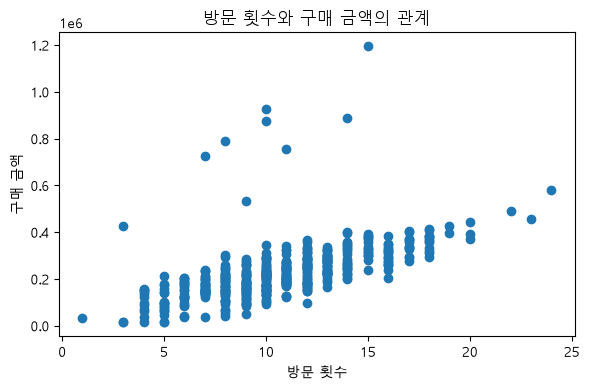

피어슨 상관계수: 0.5755135008552416


In [5]:
# 문제 2 코드를 작성하세요.
plt.figure(figsize=(6, 4))
plt.scatter(relation_df["MonthlyVisitCount"], relation_df["PurchaseAmount"])
plt.xlabel("방문 횟수")
plt.ylabel("구매 금액")
plt.title("방문 횟수와 구매 금액의 관계")
plt.tight_layout()
plt.show()

r = relation_df["MonthlyVisitCount"].corr(relation_df["PurchaseAmount"])
print("피어슨 상관계수:", r)

# 문제 3. 상관관계 결과 해석

## 업무 상황

분석팀은 산점도와 상관계수 결과를 마케팅 및 쇼핑몰 운영 담당자가 이해할 수 있도록 설명해야 합니다.

## 요구사항

다음 내용을 포함하여 **3문장 이상** 작성합니다.

1. 상관계수가 양수인지 음수인지 확인하고 관계의 방향을 설명합니다.
2. 상관계수의 절댓값을 기준으로 관계의 강도를 설명합니다.
3. 산점도의 점 분포가 상관계수의 방향 및 강도와 대체로 일치하는지 설명합니다.

## 상관계수 해석 기준

| 상관계수 절댓값 | 관계 강도 |
|---|---|
| 0.0 이상 0.3 미만 | 약한 관계 |
| 0.3 이상 0.7 미만 | 중간 정도 관계 |
| 0.7 이상 1.0 이하 | 강한 관계 |

In [6]:
# 문제 3 해석에 필요한 값을 출력하고, 아래 마크다운 셀에 해석을 작성하세요.
print("피어슨 상관계수:", r)

피어슨 상관계수: 0.5755135008552416


### 문제 3 해석 작성란

- 관계의 방향: 방문 횟수가 증가할수록 구매 금액도 증가하는 경향이 있음.
- 관계의 강도: 상관계수의 절댓값은 0.58이므로 중간 정도의 관계다.
- 일치 여부: 산점도가 전체적으로 오른쪽 윗방향으로 분포하므로 상관계수의 결과와 일치한다고 볼 수 있다.

# 심화 문제 4. 상관관계 해석의 한계와 추가 변수 제안

## 업무 상황

운영팀은 방문횟수를 늘리면 구매금액이 반드시 증가한다고 결론 내려도 되는지 확인하려고 합니다. 분석가는 상관관계 분석의 한계를 설명하고, 더 정확한 판단을 위해 추가로 확인할 고객 특성을 제안해야 합니다.

## 요구사항

다음 내용을 포함하여 작성합니다.

1. 방문횟수와 구매금액에 상관관계가 있더라도 이를 인과관계로 단정할 수 없는 이유를 설명합니다.
2. 구매금액에 함께 영향을 줄 수 있는 추가 변수 한 가지 이상을 제안합니다.
3. 제안한 변수를 함께 확인하면 어떤 점을 더 정확하게 판단할 수 있는지 설명합니다.

> Hint) 예시 변수: 고객등급, 쿠폰 사용 여부, 구매수량, 평균 상품가격, 할인 적용 여부 등

### 심화 문제 4 해석 작성란

- 인과관계로 단정할 수 없는 이유:
- 추가로 확인할 변수:
- 해당 변수를 함께 확인해야 하는 이유:

# 제출 결과물

## 필수 제출 결과물

| 결과물 | 제출 내용 |
|---|---|
| 변수 요약표 | 방문횟수와 구매금액의 평균, 최솟값, 최댓값 |
| 관계 시각화 | 방문횟수를 x축, 구매금액을 y축으로 설정한 산점도 |
| 상관관계 결과 | 피어슨 상관계수 계산 및 출력 |
| 필수 해석 | 관계의 방향·강도와 산점도 결과의 일치 여부 |

## 심화 제출 결과물

| 결과물 | 제출 내용 |
|---|---|
| 인과관계 주의점 | 상관관계를 인과관계로 단정할 수 없는 이유 |
| 추가 변수 제안 | 구매금액에 영향을 줄 수 있는 변수와 확인 이유 |

# 제출 전 체크리스트

## 필수 체크리스트

- [ ] 두 변수의 평균과 범위를 확인했습니다.
- [ ] 방문횟수를 x축으로 설정했습니다.
- [ ] 구매금액을 y축으로 설정했습니다.
- [ ] 산점도를 생성했습니다.
- [ ] 피어슨 상관계수를 계산했습니다.
- [ ] 상관관계의 방향과 강도를 설명했습니다.
- [ ] 산점도와 상관계수 결과의 일치 여부를 설명했습니다.

## 심화 체크리스트

- [ ] 상관관계를 인과관계로 단정할 수 없는 이유를 설명했습니다.
- [ ] 구매금액에 영향을 줄 수 있는 추가 변수를 한 가지 이상 제안했습니다.
- [ ] 추가 변수를 함께 확인해야 하는 이유를 설명했습니다.